In [1]:
# перед работой в kernel ставятся необходимые фреймворки 
# для этого возможен список команд:  

# python -m venv vvenvv
# source ./vvenvv/bin/activate
# pip install requirements.txt" 

# так как у меня уже есть .venv и нет requirements.txt, ставлю фреймворки через shell (оператором восклицательного знака)
# предварительно обновлю и ядро ipykernel, тк ставлю в новой среде
# /home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/bin/python -m pip install ipykernel -U  --force-reinstal

!pip install pandas numpy matplotlib seaborn scikit-learn xgboost


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# 1. Выбор начальных условий

## a. Набор данных для задачи классификации 

Реальная практическая задача:

Выявление тенденций в мед. страховании между сборами и мед. факторами согласно kaggle-page. 

- __Набор данных__: https://www.kaggle.com/datasets/muhammadanwaar101/healthcare-insurance-charges-dataset

## b. Набор данных для задачи регрессии 

Реальная практическая задача:

Выявление Хронической Болезни Почек и оценки факторов риска функции почек согласно kaggle-page.

- __Набор данных__: https://www.kaggle.com/datasets/miadul/kidney-function-health-dataset

## c. Метрики качества и обоснование выбора


### Классификация:
- __Accuracy__ - процент объектов, верно классифицированных моделью. 
- __F1-score__ - среднее гармоническое между точностью (precision) и полнотой (recall).

### Регрессия:
- __MAE__ - насколько в среднем модель ошибается в прогнозах.
- __R²__ - доля дисперсии целевой переменной, которую объясняет модель. Чем ближе к 1, тем лучше.
- __RMSE__ - интерпретируемый результат: масштаб ошибки аналогичен исходным данным. Штрафует за большие ошибки.


In [2]:
# подгрузка библиотек для получения требуемых методов. 
# библиотечные вызовы именуются в общепринятой сокращенной нотации для читаемости кода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# 1.1. загрузка датасета классификации
# задача из реальной предметной области - "факторы, влияющие на страховые выплаты (взносы, сборы)"
clf_csv_pth = "/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/dat_clf.csv"
df_clf = pd.read_csv(clf_csv_pth)

In [4]:
# 1.2 загрузка датасета регрессии
# задача из реальной предметной области - "медицинские записи с биомаркерами"
reg_csv_pth = "dat_reg.csv"
df_reg = pd.read_csv(reg_csv_pth)

In [5]:
# 1.3. исследование датасета  классификации
# производится в одном из двух форматов, доступных в пандасе. 
# взамен одномерному (1-n) series, при работе с csv рекомендуется использовать двумерный (2-n) dataframe

df_clf.head()
# вывод кортежа размерностью dataframe
df_clf_pd = pd.DataFrame(df_clf)

# применение IPython.display позволяет структурированно отобразить в консоли датафрейм
display(df_clf_pd)

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [6]:
# 1.4. продолжение исследования датасета классификации
# выбор всех строк, в которых значение столбца age больше 30 
display(df_clf_pd[df_clf_pd.AGE > 20])

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [7]:
# 1.5. исследование датасета регрессии
# окинем взглядом первые строки dataframe
df_reg.head()
df_reg.shape
# вывод обобщенного содержимого датафрейма
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   str    
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 429.8 KB


# 2. Создание бейзлайна и оценка качества

## a. Обучить модели из sklearn (для классификации и регрессии) для выбранных наборов данных



In [15]:
# 2. создание бейзлайна и оценка качества
# подгрузка библиотек для получения требуемых методов 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBClassifier, XGBRegressor

### classification_а.1. Предобработка датасета классификации

In [9]:
# 2.1. предобработка датасета классификации
# 2.1.1. очистка выбросов (IQR-интерквантильным размахом)
Q1 = df_clf['Insurance_Charges'].quantile(0.25)
Q3 = df_clf['Insurance_Charges'].quantile(0.75)
IQR = Q3 - Q1
df_ins_clean = df_clf[(df_clf['Insurance_Charges'] >= Q1 - 1.5*IQR) & 
                      (df_clf['Insurance_Charges'] <= Q3 + 1.5*IQR)].copy()

# 2.1.2. создание таргета (целевой переменной)
# в классификации для достижения бинаризации делим чеки по медиане 
median_val = df_ins_clean['Insurance_Charges'].median()
df_ins_clean['High_Charge'] = (df_ins_clean['Insurance_Charges'] > median_val).astype(int)

# 2.1.3. выделение признаков и таргета 
X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# 2.1.4. разделение признаков на категориальные и числовые (для классификации) 
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# 2.1.5. конфигурация преобразователя столбцов 
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
])

/tmp/ipykernel_79500/2148649034.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


### classification_а.2. Бейзлайн классификации

In [10]:
# 2.1.6. создание пайплайна
model_xgb = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=100,      # Количество деревьев
        learning_rate=0.1,     # Шаг обучения
        max_depth=4,           # Глубина дерева
        use_label_encoder=False, 
        eval_metric='logloss', # Метрика для оценки в процессе обучения
        random_state=42
    ))
])

# 2.1.7. разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# 2.1.8. обучение модели
model_xgb.fit(X_train, y_train)

/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:20:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### classification_b. Оценить качество моделей (для классификации) по выбранным метрикам на выбранных наборах данных



Результаты: Доля страхования (Классификация с XGBOOST)
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       157
           1       0.99      0.88      0.93       157

    accuracy                           0.94       314
   macro avg       0.94      0.94      0.94       314
weighted avg       0.94      0.94      0.94       314


Матрица ошибок:


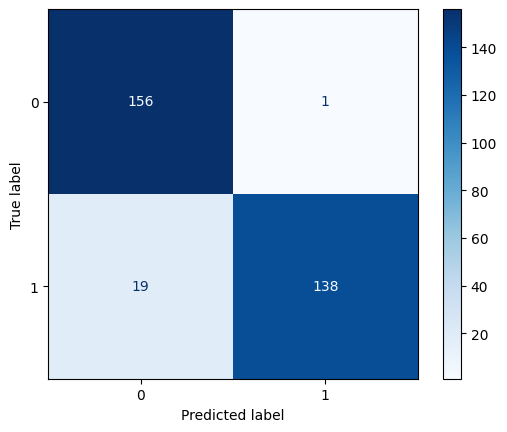

In [11]:
# 2.1.9. оценка качества модели
print("Результаты: Доля страхования (Классификация с XGBOOST)")

# получение предсказаний, вывод метрик
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

# визуализация матрицы ошибок
print("\nМатрица ошибок:")
ConfusionMatrixDisplay.from_estimator(model_xgb, X_test, y_test, cmap='Blues')

### regression_а.1. Предобработка датасета регрессии

In [12]:
# 2.2. предобработка датасета регрессии
# 2.2.1 очистка от выбросов
Q1_k = df_reg['GFR'].quantile(0.25)
Q3_k = df_reg['GFR'].quantile(0.75)
IQR_k = Q3_k - Q1_k
df_kid_clean = df_reg[(df_reg['GFR'] >= Q1_k - 1.5*IQR_k) & 
                      (df_reg['GFR'] <= Q3_k + 1.5*IQR_k)].copy()

# 2.2.2 обработка значимых признаков 
X_k = df_kid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_kid_clean['GFR']

# определение колонок
cat_cols = X_k.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.2.3 конфигурация преобразователя столбцов
preprocessor_k = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    # Для XGBoost масштабирование (StandardScaler) не обязательно
])

### regression_а.2. Бейзлайн регрессии

In [13]:
# 2.2.4 создание пайплайна

model_reg_xgb = Pipeline([
    ('pre', preprocessor_k),
    ('reg', XGBRegressor(
        n_estimators=100,      # рост числа деревьев для точности
        learning_rate=0.05,    # уменьшение шага — выше точность, дольше обучение
        max_depth=4,           # глубина деревьев — для борьбы с переобучением
        subsample=0.8,         # использование 80% данных для борьбы с переобучением
        random_state=42
    ))
])

# 2.2.5. разделение на обучающую и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42)

# 2.2.6. обучение модели
model_reg_xgb.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### regression_b. Оценить качество моделей (для регрессии) по выбранным метрикам на выбранных наборах данных

In [14]:
# 2.2.7 оценка качества модели 
y_pred_k = model_reg_xgb.predict(X_test_k)

print("\nРезультаты: оценка риска (xgboost regressor)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_k):.2f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_k):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_k):.4f}")


Результаты: оценка риска (xgboost regressor)
MAE: 6.01
MSE: 104.92
RMSE: 10.24
R2: 0.9003


# 3. Улучшение бейзлайна

1. Сформулировать гипотезы (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации и т.д.)
2. Проверить гипотезы
3. Сформировать улучшенный бейзлайн по результатам проверки гипотез

4. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных
5. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных

6. Оценить качество моделей с улучшенным бейзлайном (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

7. Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2 

8. Сделать выводы


### 3.1. Формулировка гипотез (классификация)


1. Увеличение количества деревьев (n_estimators) при одновременном снижении темпа обучения (learning_rate) позволит модели найти более тонкие закономерности без переобучения.

2. Уменьшение глубины дерева (max_depth) ограничит сложность модели, что может улучшить обобщающую способность на тестовых данных.

3. Добавление параметров регуляризации (gamma, subsample) снизит дисперсию модели и улучшит метрику F1-score для минорного класса.

### 3.2. Проверка гипотез (классификация)


In [16]:
# 1. Сетка параметров (пространство поиска)
param_dist = {
    'clf__n_estimators': [100, 200, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 4, 5, 6],
    'clf__subsample': [0.7, 0.8, 0.9],
    'clf__gamma': [0, 0.1, 0.2]
}

# 2. Инициализация поиска (RandomizedSearchCV)
# estimator: наша Pipeline, param_distributions: словарь с параметрами
random_search = RandomizedSearchCV(
    estimator=model_xgb, 
    param_distributions=param_dist,
    n_iter=10,           # Количество случайных комбинаций
    cv=5,                # Кросс-валидация
    scoring='f1_weighted',
    n_jobs=-1,           # Параллельные вычисления
    verbose=1,           # Логирование процесса
    random_state=42
)

# 3. Fit random search
random_search.fit(X_train, y_train)

# 4. Сохранение результатов в DataFrame
res_cv = pd.DataFrame(random_search.cv_results_)
print(f"Лучшие параметры: {random_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:23:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:23:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:23:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.

Лучшие параметры: {'clf__subsample': 0.9, 'clf__n_estimators': 100, 'clf__max_depth': 6, 'clf__learning_rate': 0.01, 'clf__gamma': 0.1}


### 3.3. Формирование улучшенного бейзлайна (классификация)

In [17]:
# Создание новой модели на основе лучших параметров из random_search
best_params = random_search.best_params_

model_xgb_tuned = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=best_params['clf__n_estimators'],
        learning_rate=best_params['clf__learning_rate'],
        max_depth=best_params['clf__max_depth'],
        subsample=best_params['clf__subsample'],
        gamma=best_params['clf__gamma'],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

# Обучение улучшенной модели
model_xgb_tuned.fit(X_train, y_train)

/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:24:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### 3.4. Оценка качества улучшенного бейзлайна (классификация)

In [19]:
print("РЕЗУЛЬТАТЫ: XGBOOST (УЛУЧШЕННЫЙ БЕЙЗЛАЙН)")
y_pred_tuned = model_xgb_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned))


РЕЗУЛЬТАТЫ: XGBOOST (УЛУЧШЕННЫЙ БЕЙЗЛАЙН)
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       157
           1       0.96      0.86      0.91       157

    accuracy                           0.91       314
   macro avg       0.92      0.91      0.91       314
weighted avg       0.92      0.91      0.91       314



### 3.5. Результаты проверки гипотез (классификация)



Accuracy снизилась.

### 3.6. Формулировка гипотез (регрессия). 

1. Увеличение сложности ансамбля через рост n_estimators при снижении learning_rate позволит точнее аппроксимировать непрерывную функцию GFR.

2. Введение регуляризации reg_alpha (L1) поможет автоматически исключить влияние малозначимых признаков на прогноз СКФ.

3. Настройка colsample_bytree позволит каждому дереву фокусироваться на разных наборах признаков, что снизит общую ошибку предсказания (RMSE).

### 3.7. Проверка гипотез (регрессия)


In [20]:
# 1. Сетка параметров для регрессии
param_dist_reg = {
    'reg__n_estimators': [200, 500, 1000],
    'reg__learning_rate': [0.01, 0.05, 0.1],
    'reg__max_depth': [3, 4, 6],
    'reg__colsample_bytree': [0.7, 0.8, 1.0], # Доля признаков для обучения каждого дерева
    'reg__reg_alpha': [0, 0.1, 1.0]           # L1 регуляризация
}

# 2. Инициализация поиска
# Используем MSE как негативную метрику для оптимизации
random_search_reg = RandomizedSearchCV(
    estimator=model_reg_xgb, 
    param_distributions=param_dist_reg,
    n_iter=15, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    n_jobs=-1, 
    verbose=1, 
    random_state=42
)

# 3. Обучение поиска
random_search_reg.fit(X_train_k, y_train_k)

# 4. Вывод лучших параметров
print(f"Лучшие параметры для регрессии: {random_search_reg.best_params_}")
res_cv_reg = pd.DataFrame(random_search_reg.cv_results_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Лучшие параметры для регрессии: {'reg__reg_alpha': 0, 'reg__n_estimators': 1000, 'reg__max_depth': 3, 'reg__learning_rate': 0.01, 'reg__colsample_bytree': 0.7}


### 3.8. Формирование улучшенного бейзлайна (регрессия)

In [21]:
# Извлекаем лучшие параметры
bp = random_search_reg.best_params_

model_reg_tuned = Pipeline([
    ('pre', preprocessor_k),
    ('reg', XGBRegressor(
        n_estimators=bp['reg__n_estimators'],
        learning_rate=bp['reg__learning_rate'],
        max_depth=bp['reg__max_depth'],
        colsample_bytree=bp['reg__colsample_bytree'],
        reg_alpha=bp['reg__reg_alpha'],
        random_state=42
    ))
])

# Обучение модели с оптимальными настройками
model_reg_tuned.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### 3.9. Оценка качества улучшенного бейзлайна (регрессия)

In [22]:
# Прогноз на тестовой выборке
y_pred_tuned_k = model_reg_tuned.predict(X_test_k)

print("\nРЕЗУЛЬТАТЫ: XGBOOST РЕГРЕССИЯ (УЛУЧШЕННЫЙ БЕЙЗЛАЙН)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_tuned_k):.2f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_tuned_k):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_tuned_k)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_tuned_k):.4f}")


РЕЗУЛЬТАТЫ: XGBOOST РЕГРЕССИЯ (УЛУЧШЕННЫЙ БЕЙЗЛАЙН)
MAE: 5.96
MSE: 103.98
RMSE: 10.20
R2: 0.9012


### 3.10. Результаты проверки гипотез (регрессия)


- МАЕ стал чуть меньше, метрики примерно те же.

# 4. Имплементация алгоритма машинного обучения 
1. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)

2. Обучить имплементированные модели (для классификации и регрессии) для выбранных наборов данных

3. Оценить качество имплементированных моделей (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

4. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2 

5. Сделать выводы


### 📊 Детальные метрики по категориям
<details>
<summary><b>🔍 1. Метод ближайших соседей (KNN)</b></summary>

| Модель | Accuracy 🎯 | R² Score 📈 | MAE 📏 | RMSE 📉 | Статус |
| :--- | :---: | :---: | :---: | :---: | :---: |
| sklearn baseline | 0.88 | 0.8847 | 6.3669 | 11.0150 | ✅ |
| sklearn improved | 0.9172 (0.9045) | 0.9028 (0.8890) | 5.95 | 10.11 | 🚀 |
| **MyKNN** | 0.8981 | 0.9028 | 5.9525 | 10.1106 | 🛠️ |

</details>

<details>
<summary><b>📈 2. Линейные модели (Linear & Logistic)</b></summary>

| Модель | Accuracy 🎯 | R² Score 📈 | MAE 📏 | RMSE 📉 | Статус |
| :--- | :---: | :---: | :---: | :---: | :---: |
| sklearn baseline | 0.91 | 0.8715 | 7.72 | 11.63 | ✅ |
| sklearn improved | 0.93 | 0.8963 | 6.50 | 10.44 | 🚀 |
| **Mylinreg/Mylogreg** | 0.91 | 0.8715 | 7.73 | 11.6276 | 🛠️ |

</details>

<details>
<summary><b>🌳 3. Решающее дерево (Decision Tree)</b></summary>

| Модель | Accuracy 🎯 | R² Score 📈 | MAE 📏 | RMSE 📉 | Статус |
| :--- | :---: | :---: | :---: | :---: | :---: |
| sklearn baseline | 0.91 | 0.8917 | 6.31 | 10.67 | ✅ |
| sklearn improved | 0.91 | 0.8966 | 6.38 | 10.43 | 🚀 |
| **MyDecisionTree** | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 🛠️ |

</details>

<details>
<summary><b>🌲 4. Случайный лес (Random Forest)</b></summary>

| Модель | Accuracy 🎯 | R² Score 📈 | MAE 📏 | RMSE 📉 | Статус |
| :--- | :---: | :---: | :---: | :---: | :---: |
| sklearn baseline | 0.92 | 0.9025 | 5.88 | 10.13 | ✅ |
| sklearn improved | 0.92 | 0.9045 (0.8948) | 5.91 | 10.02 | 🚀 |
| **MyRandomForest** | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 🛠️ |

</details>

<details>
<summary><b>⚡ 5. Градиентный бустинг (Gradient Boosting)</b></summary>

| Модель | Accuracy 🎯 | R² Score 📈 | MAE 📏 | RMSE 📉 | Статус |
| :--- | :---: | :---: | :---: | :---: | :---: |
| xgboost baseline | 0.94 | 0.9003 | 6.01 | 10.24 | ✅ |
| xgboost improved | 0.91 | 0.9012 | 5.96 | 10.20 | 🚀 |
| **MyGB** | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 🛠️ |

</details>